# Sales Analysis Course End Project
**Course:** Applied Data Science with Python  
**Student Name:** `Brian Gaddy`  
**Date:** `03-11-2026`  

---

## 1. Objective
 
AAL is an Australian apparel brand looking to expand. The CEO needs to identify which states generate the highest revenue and which need targeted sales programs. This analysis examines Q4 2020 sales data to provide state-wise and group-wise insights.

## 2. Data Overview

| Field | Details |
|---|---|
| **Source** | *AusApparalSales4thQrt2020.xlsx* |
| **Rows** | *7560* |
| **Columns** | *6* |
| **Date Range** | *10/1/2020 - 12/30/2020* |
| **Key Columns** | *Sales, Unit, and State* |

## 3. Imports

In [2]:
import pandas as pd
from pandas.api.types import CategoricalDtype

import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries loaded ')

Libraries loaded 


## 4. Load Data

In [3]:
# Load your dataset here
df = pd.read_excel(r"C:\Users\brian\OneDrive\Desktop\Course End Project\Sales Analysis\AusApparalSales4thQrt2020.xlsx")   # change to read_excel / read_json as needed

print(f'Shape: {df.shape}')
print(df.head())
print(df['Date'].min())
print(df['Date'].max())

Shape: (7560, 6)
        Date        Time State Age_Group  Unit  Sales
0 2020-10-01     Morning    WA      Kids     8  20000
1 2020-10-01     Morning    WA       Men     8  20000
2 2020-10-01     Morning    WA     Women     4  10000
3 2020-10-01     Morning    WA   Seniors    15  37500
4 2020-10-01   Afternoon    WA      Kids     3   7500
2020-10-01 00:00:00
2020-12-30 00:00:00


In [4]:
# Quick structural overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       7560 non-null   datetime64[ns]
 1   Time       7560 non-null   object        
 2   State      7560 non-null   object        
 3   Age_Group  7560 non-null   object        
 4   Unit       7560 non-null   int64         
 5   Sales      7560 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 354.5+ KB


---
## 5. Data Wrangling

### 5.1 Missing Value Check

In [5]:
# Check missing values
missing = df.isna().sum()
missing_pct = (df.isna().sum() / len(df) * 100).round(2)
NotNA = df.notna().sum()
missing_df = pd.DataFrame({'Missing': missing, 'Not Missing': NotNA, 'Missing %': missing_pct})
print(missing_df)

           Missing  Not Missing  Missing %
Date             0         7560       0.00
Time             0         7560       0.00
State            0         7560       0.00
Age_Group        0         7560       0.00
Unit             0         7560       0.00
Sales            0         7560       0.00


In [ ]:
# TODO: Treat missing values
# Option A — Drop rows where a critical column is null:
#   df.dropna(subset=['column_name'], inplace=True)

# Option B — Fill numeric columns with median:
#   df['column_name'].fillna(df['column_name'].median(), inplace=True)

# Option C — Fill by group (e.g., fill Income by Education + Marital Status group):

# Your code here:


**📝 Note:** *(Explain your choice — why drop vs fill? What risk does each carry for this dataset?)*

Neither of the 6 columns had missing values.

### 5.2 Data Type Fixes

In [6]:
# TODO: Fix any columns with wrong data types

#convert "Time" to categorical data type
df["Time"]=df["Time"].str.strip().str.lower()
df['Time'] = df['Time'].astype('category')

#Convert "State" to categorical without order
df['State'] = df['State'].astype('category')

#convert Age_group to string
df['Age_Group'] = df['Age_Group'].astype('string')

#Change "Age_group" to "Customer"
df = df.rename(columns={'Age_Group': 'Customer'})

I converted the Time attribute to categorcal data type and removed spaces from the text. I also converted State to a categorical data type. The age attribute was converted to a string data type and the Age_group column was renamed to Customer.

### 5.3 Normalization / Standardization

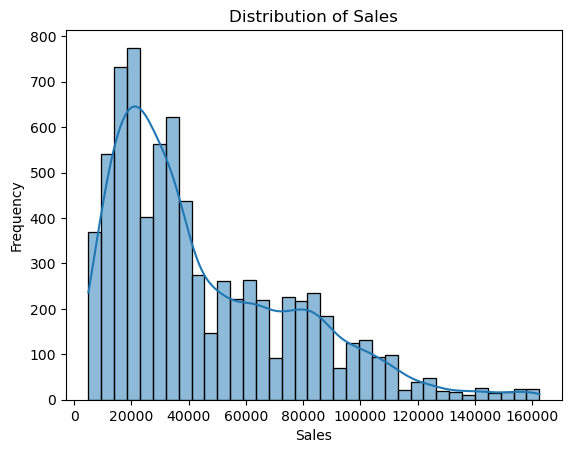

In [7]:
# TODO: Apply normalization or standardization

# Min-Max Normalization (preferred when you want values between 0 and 1):

# Z-score Standardization (preferred when data is normally distributed):

#is the dataset normally distributed?
sns.histplot(df['Sales'], kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()


In [8]:
# Use the natural logarithm to create a new feature 'Log_Sales'
df['Log_Sales'] = df['Sales'].apply(lambda x: np.log(x)) 

# Normalize 'Sales' column and create a new feature 'Normalized_Sales'
df['Normalized_Sales'] = (df['Sales'] - df['Sales'].min()) / (df['Sales'].max() - df['Sales'].min())

# Displaying the DataFrame with the new features
print("DataFrame with new features:")
print(df)


DataFrame with new features:
           Date       Time State  Customer  Unit  Sales  Log_Sales  \
0    2020-10-01    morning    WA      Kids     8  20000       9.90   
1    2020-10-01    morning    WA       Men     8  20000       9.90   
2    2020-10-01    morning    WA     Women     4  10000       9.21   
3    2020-10-01    morning    WA   Seniors    15  37500      10.53   
4    2020-10-01  afternoon    WA      Kids     3   7500       8.92   
...         ...        ...   ...       ...   ...    ...        ...   
7555 2020-12-30  afternoon   TAS   Seniors    14  35000      10.46   
7556 2020-12-30    evening   TAS      Kids    15  37500      10.53   
7557 2020-12-30    evening   TAS       Men    15  37500      10.53   
7558 2020-12-30    evening   TAS     Women    11  27500      10.22   
7559 2020-12-30    evening   TAS   Seniors    13  32500      10.39   

      Normalized_Sales  
0                 0.10  
1                 0.10  
2                 0.03  
3                 0.21  
4    

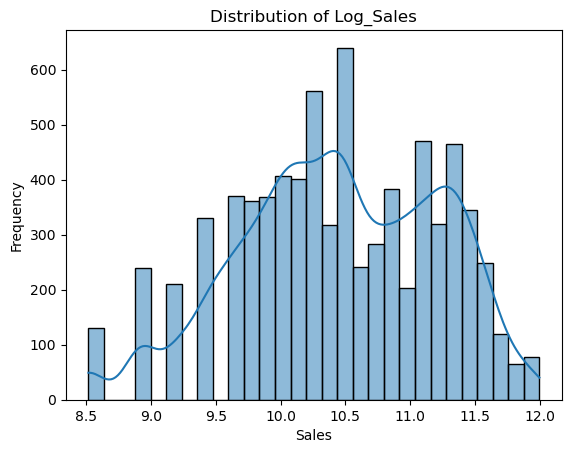

In [9]:
#is the dataset normally distributed?
sns.histplot(df['Log_Sales'], kde=True)
plt.title('Distribution of Log_Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

**📝 Note:** *(Why did you choose normalization over standardization, or vice versa?)*

The data is not normally distributed so I used normalization instead of Z-score standardization.

### 5.4 Feature Engineering *(if applicable)*

In [ ]:
# TODO: Create any derived columns your analysis needs
# Example:
#   df['Age']            = 2026 - df['Year_Birth']

# Your code here:



### 5.5 GroupBy — Chunking & Aggregation

In [24]:
# TODO: Use GroupBy to aggregate data by a meaningful dimension
state_summary = df.groupby('State').agg(
Total_Sales = ('Sales', 'sum'),
Avg_Sales   = ('Sales', 'mean'),
Total_Units = ('Unit',  'sum')
).sort_values('Total_Sales', ascending=False)
print("===== Sales by State: =====")
print(state_summary, "\n")

Time_summary = df.groupby('Time').agg(
Total_Sales = ('Sales', 'sum'),
Avg_Sales   = ('Sales', 'mean'),
Total_Units = ('Unit',  'sum')
).sort_values('Total_Sales', ascending=False)
print("===== Sales by Time: =====")
print(Time_summary, "\n")

customer_summary = df.groupby('Customer').agg(
Total_Sales = ('Sales', 'sum'),
Avg_Sales   = ('Sales', 'mean'),
Total_Units = ('Unit',  'sum')
).sort_values('Total_Sales', ascending=False)
print("===== Sales by Customer: =====")
print(customer_summary)

===== Sales by State: =====
       Total_Sales  Avg_Sales  Total_Units
State                                     
VIC      105565000   97745.37        42226
NSW       74970000   69416.67        29988
SA        58857500   54497.69        23543
QLD       33417500   30942.13        13367
TAS       22760000   21074.07         9104
NT        22580000   20907.41         9032
WA        22152500   20511.57         8861 

===== Sales by Time: =====
           Total_Sales  Avg_Sales  Total_Units
Time                                          
morning      114207500   45320.44        45683
afternoon    114007500   45241.07        45603
evening      112087500   44479.17        44835 

===== Sales by Customer: =====
          Total_Sales  Avg_Sales  Total_Units
Customer                                     
Men          85750000   45370.37        34300
Women        85442500   45207.67        34177
Kids         85072500   45011.90        34029
Seniors      84037500   44464.29        33615


**📝 Note:** *(What does this grouping reveal? Is there a natural chunking dimension in this dataset — time, state, category?)*

The GroupBy() function is useful for aggregating data based on a specific column or set of columns. In this case, I grouped the data by 'State' to calculate total sales, average sales, and total units for each state. This allows us to analyze sales performance at the state level, identify top-performing states, and make data-driven decisions. I will also group by "Time" of day and "Customer".

Recommendation: Use GroupBy() when you need to summarize or aggregate data by a specific dimension, such as state, product, or time period. This helps in gaining insights and making informed business decisions.

---
## 6. Descriptive Statistical Analysis

### 6.1 Summary Statistics

In [11]:
# TODO: Run describe() on your key numeric columns
df[['Sales', 'Unit']].describe()

,Sales,Unit
count,7560.00,7560.00
mean,45013.56,18.01
std,32253.51,12.90
min,5000.00,2.00
25%,20000.00,8.00
50%,35000.00,14.00
75%,65000.00,26.00
max,162500.00,65.00


In [12]:
# TODO: Compute mean, median, mode, std individually
for col in ['Sales', 'Unit']:
   print(f'--- {col} ---')
   print(f'  Mean   : {df[col].mean():.2f}')
   print(f'  Median : {df[col].median():.2f}')
   print(f'  Mode   : {df[col].mode()[0]:.2f}')
   print(f'  Std    : {df[col].std():.2f}')

--- Sales ---
  Mean   : 45013.56
  Median : 35000.00
  Mode   : 22500.00
  Std    : 32253.51
--- Unit ---
  Mean   : 18.01
  Median : 14.00
  Mode   : 9.00
  Std    : 12.90


**📝 Insight:** *(What does the spread tell you? Is mean ≈ median (symmetric) or far apart (skewed)?)*

The spread of both variables indicates a positively skewed distribution. For Sales, the mean (45,013.56) is noticeably higher than the median (35,000), suggesting that a few very high sales values are pulling the average upward. Similarly, for Units, the mean (18.01) is higher than the median (14), which also indicates right skewness caused by some larger purchase quantities. Because the mean is greater than the median in both cases, the data are not symmetric and the median may better represent the typical value.

### 6.2 Box Plot — Distributions & Outliers

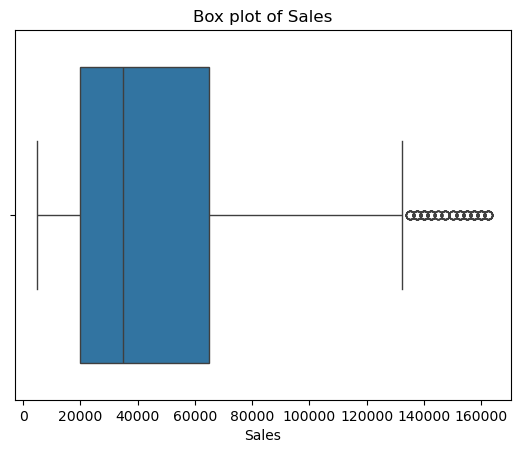

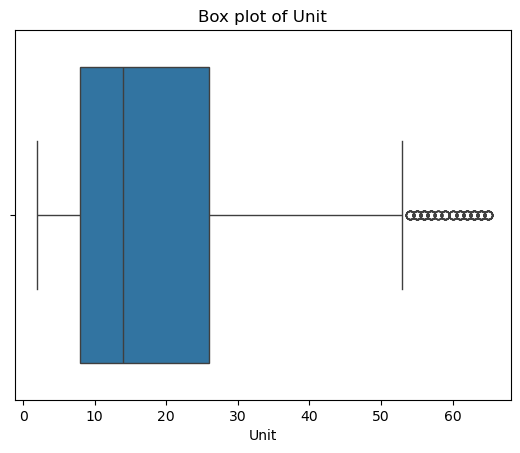

In [13]:
# TODO: Box plot on key numeric columns

import matplotlib.pyplot as plt

# Your code here:
for col in ['Sales', 'Unit']:
    sns.boxplot(x=df[col])
    plt.title(f'Box plot of {col}')
    plt.show()

**📝 Insight:** *(Are there outliers? Which direction? Do they make business sense or are they data errors?)*

Yes, there are outliers. The data is positively skewed (to the right). The data shows that there are a few large sales dollar amounts and quantities that are pulling the distribution upward and to the right. 

---
## 7. Key Findings

> Each cell below = one focused question. Lead with the chart, follow with the insight.

### 7.1 Highest & Lowest Performing Groups/Segments

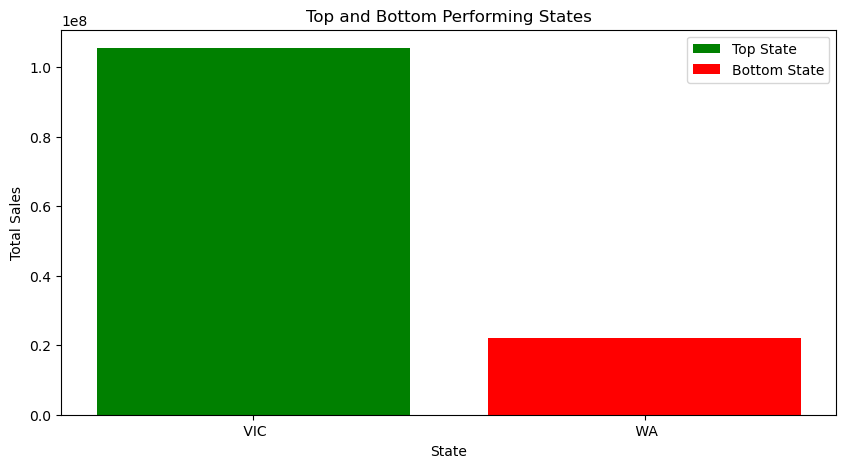

Top Performing State:
        Total_Sales  Avg_Sales  Total_Units
State                                     
VIC      105565000   97745.37        42226 

Bottom Performing State:
        Total_Sales  Avg_Sales  Total_Units
State                                     
WA        22152500   20511.57         8861 



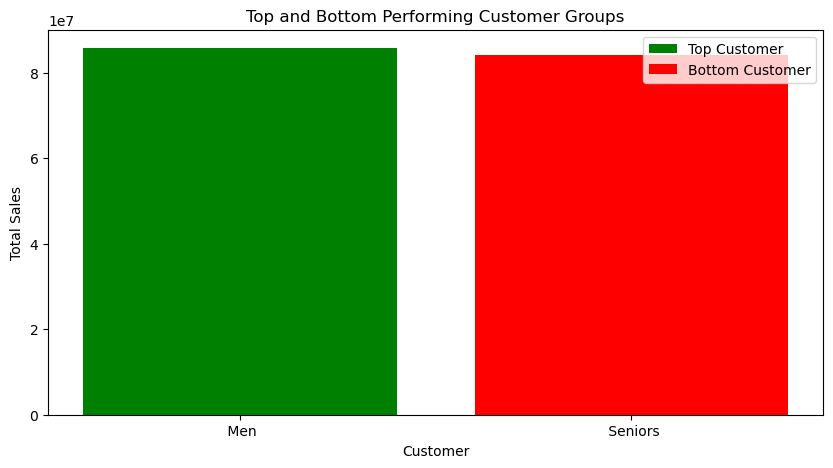

Top Performing Customer Groups:
           Total_Sales  Avg_Sales  Total_Units
Customer                                     
Men          85750000   45370.37        34300 

Bottom Performing Customer Groups:
           Total_Sales  Avg_Sales  Total_Units
Customer                                     
Seniors      84037500   44464.29        33615 



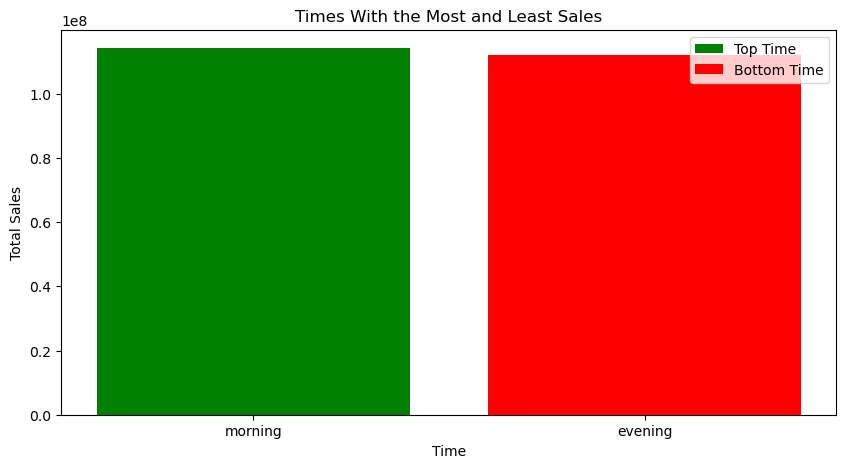

Top Performing Times:
          Total_Sales  Avg_Sales  Total_Units
Time                                        
morning    114207500   45320.44        45683 

Bottom Performing Times:
          Total_Sales  Avg_Sales  Total_Units
Time                                        
evening    112087500   44479.17        44835 



In [16]:
# TODO: Identify top and bottom performing group/state/category. 


# Top and bottom performing states
top_state = state_summary.head(1)
bottom_state = state_summary.tail(1)

plt.figure(figsize=(10, 5))
plt.bar(top_state.index, top_state['Total_Sales'], color='green', label='Top State')
plt.bar(bottom_state.index, bottom_state['Total_Sales'], color='red', label='Bottom State')
plt.title('Top and Bottom Performing States')
plt.xlabel('State')
plt.ylabel('Total Sales')
plt.legend()
plt.show()

print("Top Performing State:\n", top_state, "\n")
print("Bottom Performing State:\n", bottom_state, "\n") 

# Top and bottom performing Customer
top_customer = customer_summary.head(1)
bottom_customer = customer_summary.tail(1)

plt.figure(figsize=(10, 5))
plt.bar(top_customer.index, top_customer['Total_Sales'], color='green', label='Top Customer')
plt.bar(bottom_customer.index, bottom_customer['Total_Sales'], color='red', label='Bottom Customer')
plt.title('Top and Bottom Performing Customer Groups')
plt.xlabel('Customer')
plt.ylabel('Total Sales')
plt.legend()
plt.show()

print("Top Performing Customer Groups:\n", top_customer, "\n")
print("Bottom Performing Customer Groups:\n", bottom_customer, "\n") 

# Top and bottom performing Time
top_time = Time_summary.head(1)
bottom_time = Time_summary.tail(1)

plt.figure(figsize=(10, 5))
plt.bar(top_time.index, top_time['Total_Sales'], color='green', label='Top Time')
plt.bar(bottom_time.index, bottom_time['Total_Sales'], color='red', label='Bottom Time')
plt.title('Times With the Most and Least Sales')
plt.xlabel('Time')
plt.ylabel('Total Sales')
plt.legend()
plt.show()

print("Top Performing Times:\n", top_time, "\n")
print("Bottom Performing Times:\n", bottom_time, "\n") 


**📝 Insight:** *(Which group/state is highest? Lowest? By how much? What might explain the gap?)*

- VIC is the top performing state with total sales of 105,565,000. WA is the bottom performing state with total sales of 22,152,500. 
The gap of 83,412,500 could be due to population differences, seasonality, economic activity, or marketing efforts in each state. 

- The top performing customer group is Men with total sales of 85,750,000. The bottom performing customer group is Seniors with 
total sales of 84,037,500. The gap of 1,712,500 could be due to differences in purchasing power, preferences, or marketing targeting
for each group. 

- The time of day with the most sales is morning with a total sales of 114,207,500. Time of day with the least sales is evening with 
a total of 112,087,500. The gap of 2,120,000 could be due to differences in consumer behavior, work schedules, or promotional activities 
during different times of the day.

### 7.2 Time-based Analysis — Weekly / Monthly / Quarterly

In [34]:
# TODO: Aggregate by time period (e.g., by weekly, monthly, quarterly) and analyze trends.
weekly_sales = df.resample('W', on='Date')['Sales'].sum()
print("Weekly Sales:\n", weekly_sales, "\n")
monthly_sales = df.resample('M', on='Date')['Sales'].sum()
print("Monthly Sales:\n", monthly_sales, "\n")
quarterly_sales = df.resample('Q', on='Date')['Sales'].sum()
print("Quarterly Sales:\n", quarterly_sales, "\n")

Weekly Sales:
 Date
2020-10-04    15045000
2020-10-11    27002500
2020-10-18    26640000
2020-10-25    26815000
2020-11-01    21807500
2020-11-08    20865000
2020-11-15    21172500
2020-11-22    21112500
2020-11-29    21477500
2020-12-06    29622500
2020-12-13    31525000
2020-12-20    31655000
2020-12-27    31770000
2021-01-03    13792500
Freq: W-SUN, Name: Sales, dtype: int64 

Monthly Sales:
 Date
2020-10-31    114290000
2020-11-30     90682500
2020-12-31    135330000
Freq: ME, Name: Sales, dtype: int64 

Quarterly Sales:
 Date
2020-12-31    340302500
Freq: QE-DEC, Name: Sales, dtype: int64 



In [ ]:
# Monthly sales by state
monthly_state_sales = df.groupby([pd.Grouper(key='Date', freq='M'), 'State'])['Sales'].sum().unstack()
print("Monthly Sales by State:\n", monthly_state_sales, "\n")

Monthly Sales by State:
 State            NSW       NT       QLD        SA      TAS       VIC       WA
Date                                                                         
2020-10-31  25007500  8222500  11120000  20610000  8015000  33442500  7872500
2020-11-30  21490000  5257500   8110000  15532500  5545000  29530000  5217500
2020-12-31  28472500  9100000  14187500  22715000  9200000  42592500  9062500 



In [36]:
# Monthly sales by customer
monthly_customer_sales = df.groupby([pd.Grouper(key='Date', freq='M'), 'Customer'])['Sales'].sum().unstack()
print("Monthly Sales by Customer:\n", monthly_customer_sales, "\n")

Monthly Sales by Customer:
 Customer        Kids       Men   Seniors     Women
Date                                              
2020-10-31  28635000  28885000  28565000  28205000
2020-11-30  22882500  22615000  22322500  22862500
2020-12-31  33555000  34250000  33150000  34375000 



**📝 Insight:** *(Any seasonality? Peak weeks or months? Dips worth investigating?)*

The data shows a clear seasonal trend toward the end of the year. Weekly sales increase significantly in December, with the highest sales occurring during the weeks of December 20 (31,655,000) and December 27 (31,770,000). This suggests a holiday-related peak, likely driven by increased consumer spending during the holiday shopping season.

In contrast, sales are lower at the beginning of October (15,045,000) and drop again in the first week of January (13,792,500), which may reflect typical post-holiday demand declines. Monthly totals reinforce this pattern, with December (135,330,000) outperforming both October (114,290,000) and November (90,682,500). Overall, the trend indicates strong holiday seasonality with peaks in late December and noticeable dips before and immediately after the holiday period, which may warrant further investigation for inventory and marketing planning.

### 7.3 *(Add more finding sections as needed)*

In [ ]:
# Your code here:


**📝 Insight:**

---
## 8. Dashboard / Visualizations

> Build a 2×2 or 2×3 subplot dashboard covering your key parameters.  
> Every chart must have a title. Every chart must be followed by a 1-line takeaway.

In [ ]:
# TODO: Build your main dashboard using Plotly or Seaborn

# Plotly template:
# fig = make_subplots(rows=2, cols=2, subplot_titles=('Chart 1', 'Chart 2', 'Chart 3', 'Chart 4'))
# fig.add_trace(go.Bar(...), row=1, col=1)
# fig.add_trace(go.Bar(...), row=1, col=2)
# fig.add_trace(go.Bar(...), row=2, col=1)
# fig.add_trace(go.Scatter(...), row=2, col=2)
# fig.update_layout(title='Dashboard Title', height=750, template='plotly_white')
# fig.show()

# Use seaborn to construct a dashboard for the head of sales and marketing. The dashboard should encompass key parameters: 
# State-wise sales analysis for different demographic groups (kids, women, men, and seniors).
# Group-wise sales analysis (Kids, Women, Men, and Seniors) across various states. 
# Time-of-the-day analysis: Identify peak and off-peak sales periods to facilitate strategic planning for S&M teams. This information aids in designing programs like hyper-personalization and Next Best Offers to enhance sales. 
fig = make_subplots(rows=2, cols=2, subplot_titles=('Sales by State', 'Sales by Customer', 'Sales Over Time', 'Sales Distribution'))
fig.add_trace(go.Bar(x=state_summary.index, y=state_summary['Total_Sales'], name='Sales by State'), row=1, col=1)
fig.add_trace(go.Bar(x=customer_summary.index, y=customer_summary['Total_Sales'], name='Sales by Customer'), row=1, col=2)
fig.add_trace(go.Scatter(x=weekly_sales.index, y=weekly_sales.values, mode='lines+markers', name='Sales Over Time'), row=2, col=1)
fig.add_trace(go.Histogram(x=df['Sales'], name='Sales Distribution'), row=2, col=2)
fig.update_layout(title='Sales Analysis Dashboard', height=750, template='plotly_white')
fig.show()

**📝 Dashboard Takeaway:** *(Summarize what the dashboard shows in 2–3 sentences. What stands out?)*

WA has significantly lower revenue than VIC. Sales do not vary much across the customer groups. Sales are lower at the beginning of October, drop again in the first week of January, but spike towrards late December. I chose the Seaborn dashboard since we are working with statistical data.

---
## 9. Recommendations

> Be specific. Every recommendation should connect back to a finding above.  
> Avoid vague statements like "improve sales" — say *where*, *how*, and *why*.

| # | Finding | Recommendation | Priority |
|---|---|---|---|
| 1 | WA has approximately 79% lower revenue than VIC | To increase sales in WA, the company should analyze the strategies used in VIC (such as successful promotions, product mix, and distribution channels) and replicate or adapt those tactics in WA while also increasing localized marketing and promotional campaigns to drive demand. | High |
| 2 | There is a significant spike in sales during December. | Increase marketing promotions and inventory availability in early December through the last two weeks of December, since the data shows sales peak during the holiday period and additional promotion during this high-demand window could further boost revenue. | High |
| 3 | | | |
| 4 | | | |

---
## 10. Conclusion

> 4–6 sentences max. Answer the original business question stated in Section 1.  
> Do not introduce new findings here — only summarize.

The analysis shows that VIC is the state generating the highest revenue, with total sales of 105,565,000, significantly outperforming the other states. In contrast, WA is the lowest performing state, generating 22,152,500 in total sales. This indicates that WA produces substantially less revenue compared to the top-performing state. To improve performance, the business should develop targeted sales programs in WA, such as localized promotions, improved product availability, and marketing strategies similar to those successfully used in VIC. Focusing resources on lower-performing states can help close the revenue gap and increase overall sales performance.

## 11. Future Scope(Optional)

  Something you think as an extra steps or advanced analysis that can be done.